# 01 – Cable Calibration Signal Cleaning

This notebook:
- Loads raw VLBI cable calibration data
- Applies MAD-based discontinuity correction
- Outputs cleaned time series for downstream analysis

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.append(os.path.abspath("../src"))

from mad_detection import reconstruct_cablecal

## 1.1 KP-VLBA Station Analysis

In [2]:
data_path = "../data/raw/kp_vlba_2020-05-12.csv"
df_kp = pd.read_csv(data_path)

df_kp.head()

,time,cablecal,temp,pressure,humid
0,12-05-20 11:50:02,4.785224,14.234000,810.8,0.332793
1,12-05-20 11:52:05,4.750748,14.275000,810.8,0.325928
2,12-05-20 11:54:49,4.769335,14.270432,810.8,0.319564
3,12-05-20 11:57:43,4.746251,14.212625,810.8,0.315304
4,12-05-20 12:01:42,4.841585,14.266777,810.8,0.308423


In [3]:
df_kp = reconstruct_cablecal(df_kp)
df_kp.head()

,time,cablecal,temp,pressure,humid,cablecal_baseline,cablecal_clean
0,2020-05-12 11:50:02,4.785224,14.234000,810.8,0.332793,4.785224,4.785224
1,2020-05-12 11:52:05,4.750748,14.275000,810.8,0.325928,4.750748,4.750748
2,2020-05-12 11:54:49,4.769335,14.270432,810.8,0.319564,4.769335,4.769335
3,2020-05-12 11:57:43,4.746251,14.212625,810.8,0.315304,4.746251,4.746251
4,2020-05-12 12:01:42,4.841585,14.266777,810.8,0.308423,4.841585,4.841585


The function reconstructs the cable calibration time series by first
detecting discontinuities using MAD. The stable samples are separated
and retained as a reference baseline (`cablecal_baseline`). The remaining
discontinuous segments are then reconstructed, and the final corrected
signal (`cablecal_clean`) is selected based on its correlation with
environmental variables (temperature, pressure, humidity).

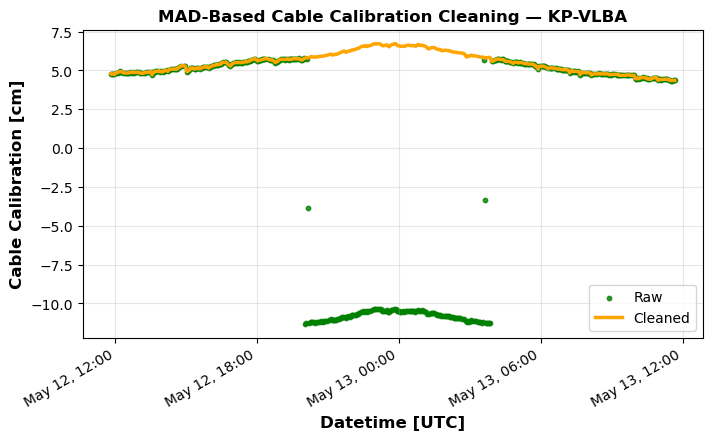

In [4]:
plt.figure(figsize=(8,4))

plt.scatter(df_kp["time"], df_kp["cablecal"], s=10, alpha=0.8, label="Raw", color="green")
plt.plot(df_kp["time"], df_kp["cablecal_clean"], linewidth=2.5, label="Cleaned", color="orange")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %H:%M'))  
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))  
plt.gca().xaxis.set_major_locator(mdates.HourLocator(byhour=[12, 18, 0, 6]))
plt.xticks(rotation=30, ha='right')
plt.yticks(fontsize=10)

plt.title("MAD-Based Cable Calibration Cleaning — KP-VLBA", fontsize=12, fontweight='bold')
plt.xlabel('Datetime [UTC]', fontsize=12, fontweight='bold')
plt.ylabel('Cable Calibration [cm]', fontsize=12, fontweight='bold')

plt.grid(True, linestyle='-', alpha=0.3)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10, loc='lower right')
plt.show()

In [5]:
r_raw_temp_kp = np.corrcoef(df_kp["cablecal"], df_kp["temp"])[0,1]
r_raw_pressure_kp = np.corrcoef(df_kp["cablecal"], df_kp["pressure"])[0,1]
r_raw_humid_kp = np.corrcoef(df_kp["cablecal"], df_kp["humid"])[0,1]

r_clean_temp_kp = np.corrcoef(df_kp["cablecal_clean"], df_kp["temp"])[0,1]
r_clean_pressure_kp = np.corrcoef(df_kp["cablecal_clean"], df_kp["pressure"])[0,1]
r_clean_humid_kp = np.corrcoef(df_kp["cablecal_clean"], df_kp["humid"])[0,1]

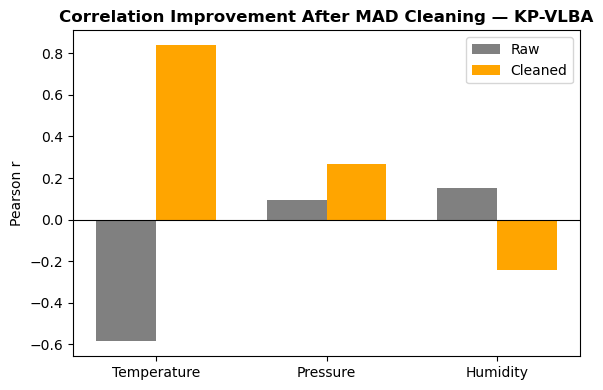

In [6]:
labels = ['Temperature', 'Pressure', 'Humidity']

raw_vals_kp = [r_raw_temp_kp, r_raw_pressure_kp, r_raw_humid_kp]
clean_vals_kp = [r_clean_temp_kp, r_clean_pressure_kp, r_clean_humid_kp]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,4))

plt.bar(x - width/2, raw_vals_kp, width, label='Raw', color='gray')
plt.bar(x + width/2, clean_vals_kp, width, label='Cleaned',color='orange')
plt.axhline(0, color='black', linewidth=0.8)

plt.xticks(x, labels)
plt.ylabel('Pearson r')
plt.title('Correlation Improvement After MAD Cleaning — KP-VLBA', fontsize=12, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

In [7]:
summary_kp = pd.DataFrame({
    "Metric": ["Mean [cm]", "Std Dev [cm]", "Sample Size"],
    "Raw": [np.mean(df_kp["cablecal"]), np.std(df_kp["cablecal"]), len(df_kp["cablecal"])],
    "Cleaned": [np.mean(df_kp["cablecal_clean"]), np.std(df_kp["cablecal_clean"]), len(df_kp["cablecal_clean"])]})

summary_kp.round(2)

,Metric,Raw,Cleaned
0,Mean [cm],0.14,5.50
1,Std Dev [cm],7.39,0.65
2,Sample Size,453.00,453.00


In [8]:
std_reduction_kp = 100 * (np.std(df_kp["cablecal"]) - np.std(df_kp["cablecal_clean"])) / np.std(df_kp["cablecal"])

print(f"Std reduction: {std_reduction_kp:.2f}%")

Std reduction: 91.27%


MAD-based cleaning removes non-physical offsets and restores a physically consistent signal. Temperature correlation increases substantially after correction, while overall signal variability decreases. The cleaned series preserves the temporal trend and exhibits improved agreement with the environmental factors, indicating removal of discontinuity-induced artifacts.

## 1.2 OV-VLBA Station Analysis

In [9]:
data_path = "../data/raw/ov_vlba_2020-02-20.csv"
df_ov = pd.read_csv(data_path)

df_ov.head()

,time,cablecal,temp,pressure,humid
0,20-02-20 9:47:04,3.672474,0.465116,886.890698,0.378240
1,20-02-20 9:48:55,3.663180,0.344850,886.900000,0.370102
2,20-02-20 9:50:26,3.651488,0.284385,886.900000,0.357508
3,20-02-20 9:52:30,3.653287,0.201993,886.900000,0.340346
4,20-02-20 9:55:01,3.454225,0.298339,886.998339,0.352975


In [10]:
df_ov = reconstruct_cablecal(df_ov)
df_ov.head()

,time,cablecal,temp,pressure,humid,cablecal_baseline,cablecal_clean
0,2020-02-20 09:47:04,3.672474,0.465116,886.890698,0.378240,3.672474,3.672474
1,2020-02-20 09:48:55,3.663180,0.344850,886.900000,0.370102,3.663180,3.663180
2,2020-02-20 09:50:26,3.651488,0.284385,886.900000,0.357508,3.651488,3.651488
3,2020-02-20 09:52:30,3.653287,0.201993,886.900000,0.340346,3.653287,3.653287
4,2020-02-20 09:55:01,3.454225,0.298339,886.998339,0.352975,3.454225,3.454225


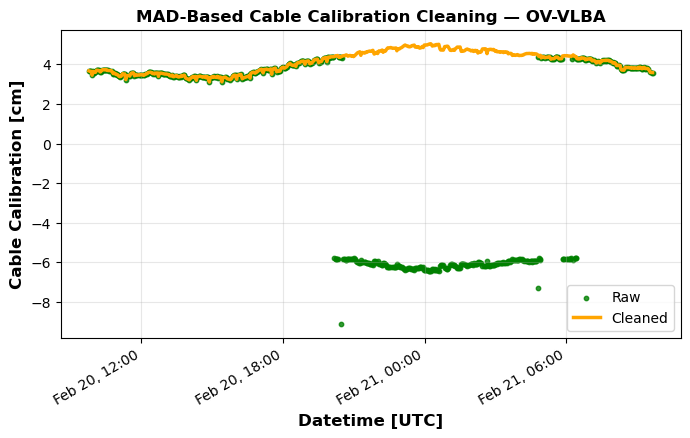

In [11]:
plt.figure(figsize=(8,4))

plt.scatter(df_ov["time"], df_ov["cablecal"], s=10, alpha=0.8, label="Raw", color="green")
plt.plot(df_ov["time"], df_ov["cablecal_clean"], linewidth=2.5, label="Cleaned", color="orange")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %H:%M'))  
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))  
plt.gca().xaxis.set_major_locator(mdates.HourLocator(byhour=[12, 18, 0, 6]))
plt.xticks(rotation=30, ha='right')
plt.yticks(fontsize=10)

plt.title("MAD-Based Cable Calibration Cleaning — OV-VLBA", fontsize=12, fontweight='bold')
plt.xlabel('Datetime [UTC]', fontsize=12, fontweight='bold')
plt.ylabel('Cable Calibration [cm]', fontsize=12, fontweight='bold')

plt.grid(True, linestyle='-', alpha=0.3)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10, loc='lower right')
plt.show()

In [12]:
r_raw_temp_ov = np.corrcoef(df_ov["cablecal"],df_ov["temp"])[0,1]
r_raw_pressure_ov = np.corrcoef(df_ov["cablecal"],df_ov["pressure"])[0,1]
r_raw_humid_ov = np.corrcoef(df_ov["cablecal"],df_ov["humid"])[0,1]

r_clean_temp_ov = np.corrcoef(df_ov["cablecal_clean"], df_ov["temp"])[0,1]
r_clean_pressure_ov = np.corrcoef(df_ov["cablecal_clean"], df_ov["pressure"])[0,1]
r_clean_humid_ov = np.corrcoef(df_ov["cablecal_clean"], df_ov["humid"])[0,1]

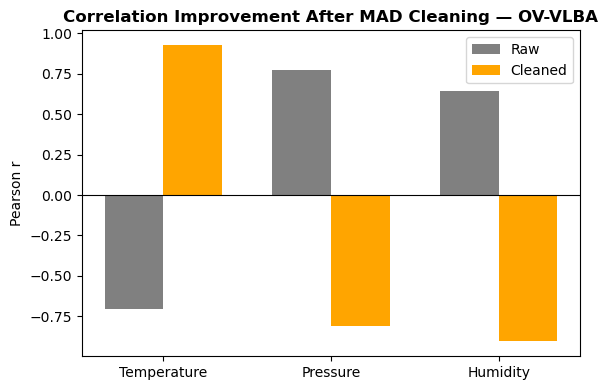

In [13]:
labels = ['Temperature', 'Pressure', 'Humidity']

raw_vals_ov = [r_raw_temp_ov, r_raw_pressure_ov, r_raw_humid_ov]
clean_vals_ov = [r_clean_temp_ov, r_clean_pressure_ov, r_clean_humid_ov]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,4))

plt.bar(x - width/2, raw_vals_ov, width, label='Raw', color='gray')
plt.bar(x + width/2, clean_vals_ov, width, label='Cleaned',color='orange')
plt.axhline(0, color='black', linewidth=0.8)

plt.xticks(x, labels)
plt.ylabel('Pearson r')
plt.title('Correlation Improvement After MAD Cleaning — OV-VLBA', fontsize=12, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

In [14]:
summary_ov = pd.DataFrame({
    "Metric": ["Mean [cm]", "Std Dev [cm]", "Sample Size"],
    "Raw": [np.mean(df_ov["cablecal"]), np.std(df_ov["cablecal"]), len(df_ov["cablecal"])],
    "Cleaned": [np.mean(df_ov["cablecal_clean"]), np.std(df_ov["cablecal_clean"]), len(df_ov["cablecal_clean"])]})

summary_ov.round(2)

,Metric,Raw,Cleaned
0,Mean [cm],0.17,4.10
1,Std Dev [cm],4.76,0.53
2,Sample Size,682.00,682.00


In [15]:
std_reduction_ov = 100 * (np.std(df_ov["cablecal"]) - np.std(df_ov["cablecal_clean"])) / np.std(df_ov["cablecal"])

print(f"Std reduction: {std_reduction_ov:.2f}%")

Std reduction: 88.85%


Similar discontinuity behavior is observed at OV-VLBA. After cleaning, the cable calibration signal shows improved environmental agreement and reduced artificial variability. The method demonstrates consistent performance across independent stations.

## 1.3 Cross-Station Summary

In [16]:
summary_df = pd.DataFrame({
    "Station": ["KP-VLBA", "OV-VLBA"],
    "r_raw (Temp)": [r_raw_temp_kp, r_raw_temp_ov],
    "r_clean (Temp)": [r_clean_temp_kp, r_clean_temp_ov],
    "Δr (Temp)": [
        r_clean_temp_kp - r_raw_temp_kp,
        r_clean_temp_ov - r_raw_temp_ov
    ],
    "Std Raw": [np.std(df_kp["cablecal"]), np.std(df_ov["cablecal"])],
    "Std Clean": [np.std(df_kp["cablecal_clean"]), np.std(df_ov["cablecal_clean"])],
    "Std Reduction (%)": [std_reduction_kp, std_reduction_ov]
})

summary_df = summary_df.round(2)
summary_df

,Station,r_raw (Temp),r_clean (Temp),Δr (Temp),Std Raw,Std Clean,Std Reduction (%)
0,KP-VLBA,-0.59,0.84,1.43,7.39,0.65,91.27
1,OV-VLBA,-0.71,0.93,1.63,4.76,0.53,88.85


Across both stations, MAD-based cleaning substantially improves temperature correlation (Δr > 1.4) and reduces artificial signal variability by ~90%, indicating successful removal of discontinuity-induced offsets.